# **Hoja de trabajo #2**

- Paula Barillas - 22764
- Gerardo Pineda - 22880
- Mónica Salvatierra - 22249

Link del repositorio: https://github.com/paulabaal12/HT2-VPC

## **Task 1 - Análisis**

1. **Durante una prueba, el robot gira sobre su propio eje para escanear el entorno. El ingeniero junior a tu cargo sugiere usar Homografías para medir la distancia a los objetos mientras el robot gira. ¿Es este un enfoque correcto? Justifique su respuesta utilizando los conceptos de C1, C2 y Paralaje.**

- Consideramos que no sería correcto usar homografías para medir distancia si el robot únicamente está girando sobre su propio eje. Cuando el robot gira, las cámaras en C1 y C2 solo cambian su orientación, pero no existe traslación. En estas condiciones no hay paralaje real, dado que la paralaje surge cuando hay desplazamiento entre posiciones de cámara y los objetos cercanos se proyectan con mayor desplazamiento en la imagen que los objetos lejanos.

    Las homografías permiten alinear imágenes cuando existe rotación o cuando la escena es prácticamente plana, pero no permiten recuperar información de profundidad si no hay traslación. Como entre C1 y C2 no se genera paralaje durante la rotación, no es posible estimar la distancia Z a los objetos. Por esta razón, este enfoque no es adecuado para medir distancia mientras el robot solo está girando.

2. **Si el robot comienza a avanzar (traslación) y detectas que la disparidad (d) de una caja aumenta repentinamente entre el frame t y el frame t+1, ¿qué puedes inferir sobre la  distancia (Z) entre el robot y la caja? ¿Qué riesgo industrial implicaría un error en el cálculo de esta disparidad?**

- Si el robot comienza a avanzar y la disparidad (d) de una caja aumenta entre el frame t y el frame t+1, significa que la caja está más cerca del robot. Esto se debe a que la profundidad y la disparidad tienen una relación inversa. Cuando la disparidad aumenta, la distancia disminuye, entonces, podemos inferir que el robot se está acercando a la caja.

    Si el cálculo de la disparidad es incorrecto, el robot podría estimar mal la distancia real al objeto. Por ejemplo, podría creer que la caja está más lejos de lo que realmente está y no frenar a tiempo, lo que implicaría riesgo de colisión. En un entorno industrial, esto podría causar daños materiales o incluso representar un peligro para la seguridad.

# TASK 2 -Ingeniería de Dimensiones.

1. Utilizando la fórmula vista en clase, calcule las dimensiones (Wout,Hout) del Mapa de Características
resultante. Muestra el procedimiento.

W = 1280  
H = 720  
F = 5  
P = 2  
S = 2  
  
### Ancho
$$

W = \left[ \frac{(w - k + 2P)}{s} \right] + 1

$$

$$
W = \left[ \frac{(1280 - 5 + 2(2))}{2} \right] + 1
$$
$$
W = \left[ \frac{1279}{2} \right] + 1
$$
$$
W = Floor(\left[ 639.5 \right]) + 1
$$
$$
W = 639 + 1 = 640
$$
---
### Alto
$$
H = \left[ \frac{(w - k + 2P)}{s} \right] + 1
$$
$$
H = \left[ \frac{(720 - 5 + 2(2))}{2} \right] + 1
$$
$$
H = \left[ \frac{719}{2} \right] + 1
$$
$$
H = Floor(\left[ 359.5 \right]) + 1
$$
$$
H = 359 + 1 = 360
$$

**Dimensiones finales** = (640,360)

2. ¿Qué sucedería con el tamaño de la salida si decides cambiar el Padding a P=0 (Valid Padding)?
¿Cómo afectaría esto a la información de los bordes de la imagen (donde suelen estar las referencias
de las paredes del almacén)?  

$$
W = \left[ \frac{1280 - 5 + 0}{2} \right] + 1
$$
$$
W = \left[ \frac{1275}{2} \right] + 1
$$
$$
W = 637 + 1 = 638
$$
---
### Alto
$$
H = \left[ \frac{720 - 5 + 0}{2} \right] + 1
$$
$$
H = \left[ \frac{715}{2} \right] + 1
$$
$$
H = 357 + 1 = 358
$$

**Dimensiones finales** = (638,358)

En el filtro se pierden los pixeles de los bordes, las ultimas y primeras filas no influyen en la salida. Afectando la detecciond e geometria o profundidad. Por eso se suele usar P = 2 para preservar información espacial.


# TASK 3 - Criterios de Diseño

1. Usted está desarrollando un sistema de detección de grietas microscópicas en motores de avión.
¿Qué combinación de Stride y Pooling recomendaría para no perder detalles críticos en las
primeras capas de la red? Justifique técnicamente.

Para detectar las gritas se necesita precisión, por lo tanto, se necesita usar un stride de 1 para que el filtro analice la imagen pixel por pixel y no reduce la resolución. si se utilizara un stride mayor a 2, se perderia información muy rapido porque la imagen se hace mas pequeña cada vez de forma mas rapida. El pooling no es necesario para las primeras capas, cuando ya se hayan extraido las caracteristicas, porque el pooling reduce el tamaño del mapa y aumenta el canal, entonces es mejor hacer primero caracteristicas importantes.

2. Un cliente le pide que el sistema funcione en un procesador muy limitado (como una cámara
inteligente con poca RAM). Explique cómo podrías utilizar el Stride y el Max Pooling
estratégicamente para reducir la carga computacional sin eliminar las características más fuertes
(activaciones) del Mapa de Características

si el sistema debe funcionar con un sistema de recursos limitados, con una camara inteligente con poca RAM. Aqui si conviene usar un strid mayor 2 porque se reduce la imagen mas rapido y los calculos bajan drasticamente, se podria integrear un max pooling de 2x2, debido a que obtiene mas data del mapa de caracteristicas, mientras reduce las dimensionales. De esta menra se logra que el modelo sea liviano y rapido.

## **Task 4 - Implementación Práctica**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
def manual_convolution(image, kernel, stride=1, padding=0):
    H, W = image.shape
    F = kernel.shape[0]

    padded_image = np.pad(
        image,
        pad_width=((padding, padding), (padding, padding)),
        mode="constant",
        constant_values=0,
    )

    H_p, W_p = padded_image.shape
    out_h = int((H_p - F) / stride) + 1
    out_w = int((W_p - F) / stride) + 1

    output = np.zeros((out_h, out_w), dtype=np.float32)

    for i in range(out_h):
        for j in range(out_w):
            start_i = i * stride
            start_j = j * stride
            patch = padded_image[start_i:start_i + F, start_j:start_j + F]
            output[i, j] = np.sum(patch * kernel)

    return output

Tamaño imagen pequeña (entrada): (5, 5)
Tamaño feature map (S=1, P=0): (5, 5)


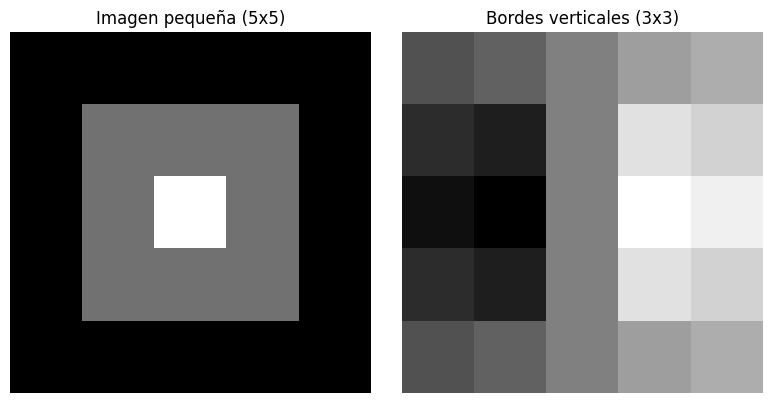

In [ ]:
# Imagen pequeña sintética (5x5) y filtro de bordes verticales
vertical_edge_kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=np.float32)

small_image = np.array([
    [10, 10, 10, 10, 10],
    [10, 50, 50, 50, 10],
    [10, 50,100, 50, 10],
    [10, 50, 50, 50, 10],
    [10, 10, 10, 10, 10]
], dtype=np.float32)

small_feature_map = manual_convolution(
    small_image,
    vertical_edge_kernel,
    stride=1,
    padding=1,
)

print("Tamaño imagen pequeña (entrada):", small_image.shape)
print("Tamaño feature map (S=1, P=1):", small_feature_map.shape)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Imagen pequeña (5x5)")
plt.imshow(small_image, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Bordes verticales (3x3)")
plt.imshow(small_feature_map, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

Tamaño imagen original: (960, 1280)
Tamaño feature map (S=1, P=0): (958, 1278)


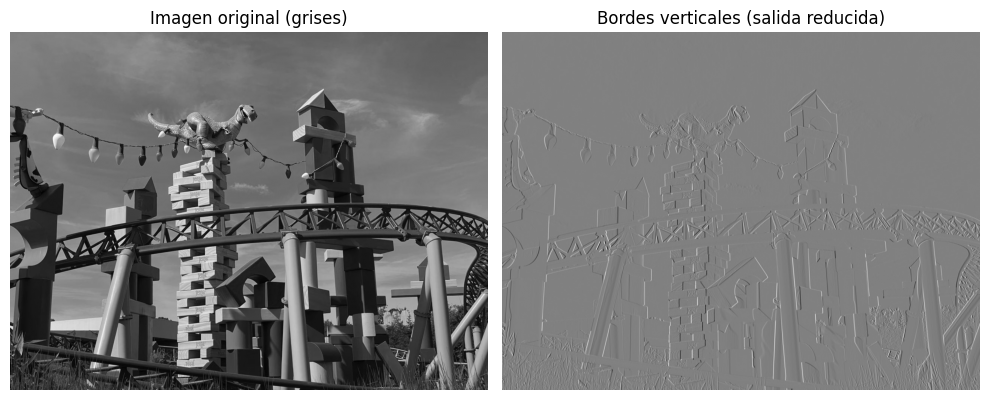

In [4]:
# Prueba con una imagen real
img_color = mpimg.imread("img/task4.jpeg")

# Conversión a escala de grises (asumimos imagen RGB)
image_gray = (
    0.299 * img_color[..., 0]
    + 0.587 * img_color[..., 1]
    + 0.114 * img_color[..., 2]
)

print("Tamaño imagen original:", image_gray.shape)

# Filtro Sobel para bordes verticales (Sobel en X)
sobel_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

result_real = manual_convolution(
    image_gray,
    sobel_vertical,
    stride=1,
    padding=0,
)

print("Tamaño feature map (S=1, P=0):", result_real.shape)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Imagen original (grises)")
plt.imshow(image_gray, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Bordes verticales (salida reducida)")
plt.imshow(result_real, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

P=1, S=1 -> salida shape: (960, 1280)
P=1, S=4 -> salida shape: (240, 320)
P=4, S=1 -> salida shape: (966, 1286)
P=4, S=4 -> salida shape: (242, 322)


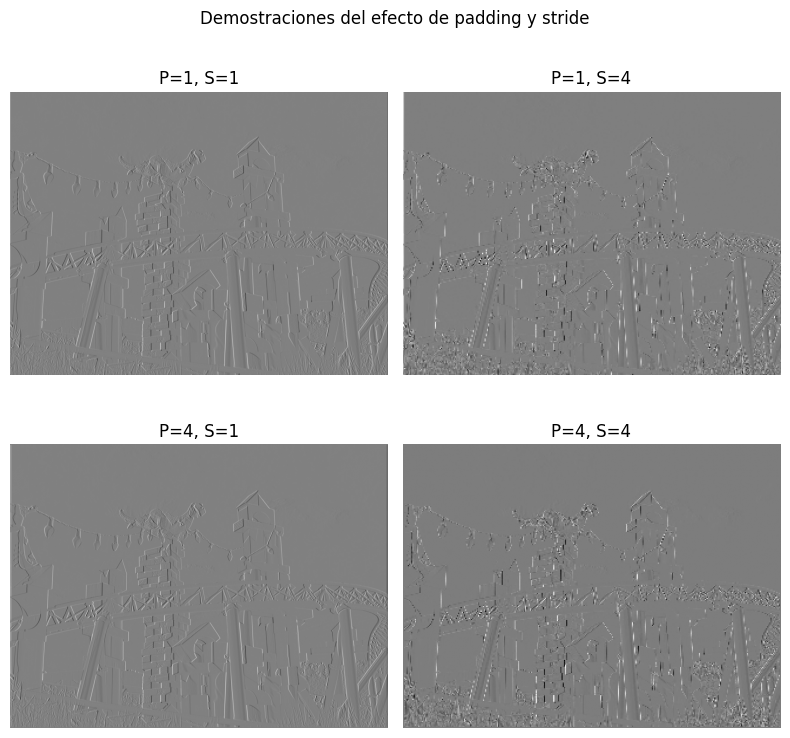

In [6]:
configs = [(1, 1), (1, 4), (4, 1), (4, 4)]
plt.figure(figsize=(8, 8))
for idx, (p, s) in enumerate(configs, start=1):
    feature_map = manual_convolution(image_gray, sobel_vertical, stride=s, padding=p)
    print(f"P={p}, S={s} -> salida shape: {feature_map.shape}")
    plt.subplot(2, 2, idx)
    plt.title(f"P={p}, S={s}")
    plt.imshow(feature_map, cmap="gray")
    plt.axis("off")

plt.suptitle("Demostraciones del efecto de padding y stride", y=0.98)
plt.tight_layout()
plt.show()


Para una imagen de entrada de tamaño $H \times W$ y un kernel cuadrado de tamaño $F \times F$, con padding $P$ y stride $S$, el tamaño de la salida (feature map) se calcula como

   $salida = \frac{W - F + 2P}{S} + 1$.

En donde si hacemos uso de  padding = 0 , la salida es en teoría es más pequeña que la imagen original. Por lo cuál si aumentamos el padding, se puede mantener el mismo tamaño espacial que la entrada (agregando ceros). Ahora en el caso de aumento de stride, el kernel se va desplazando con saltos más grandes y el feature map resultante se vuelve todavía más pequeño representando o bien siendo menor resolución espacial donde por ejemplo en el caso de los bordes se irián perdiendo.


## **Prompt Utilizado**
**Uso de ChatGPT**

**Task 4**

Para la cuarta tarea le pedimos que nos guiara para definir correctamente un filtro de detección de bordes verticales (tipo Sobel), en donde pudieramos aplicarlo primero a una imagen pequeña de prueba de 5×5 píxeles y luego a una imagen real, verificando que los tamaños de salida coincidieran con la fórmula teórica de la convolución.En donde también utilizamos el modelo para generar demostraciones adicionales que comparan distintos valores de stride y padding, de forma que se pudiera visualizar claramente cómo cambian el tamaño del feature map y el nivel de detalle de los bordes detectados.



**Por qué funcionó este prompt**

Al dar ejemplos concretos (imagen 5×5, kernel 3×3, combinaciones específicas de ` y S), ChatGPT pudo proponer código bastante entendible en el que luego ajustamos a nuestras necesidades, manteniendo la lógica central y usando NumPy solo para el manejo básico de matrices.
